# E-commerce Dataset Preprocessing Tutorial


## 🎯 Objective
In this tutorial, we'll cover the **entire data preprocessing pipeline** for the Titanic dataset, including:

- **Data Cleaning**
- **Data Transformation**
- **Data Encoding** (Multiple Techniques)
- **Data Scaling** (All Major Methods with Comparison)

We will also conclude with **best practices** and **recommendations**.

Each section includes **why it's needed**, and **before-and-after transformations** to give a clear, instructional overview.

## 📦 1. Load E-commerce Dataset

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew

df = pd.read_csv('train.csv')
print("INITIAL DATA OVERVIEW")
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())


INITIAL DATA OVERVIEW
Dataset shape: (18000, 17)

First 5 rows:
   id                 date region       channel product_category  \
0   1  2011-12-05 11:31:00   Nort        Search          General   
1   2  2011-04-27 14:01:00  North  Social Media          General   
2   3  2010-11-09 15:20:00  North     Affiliate          General   
3   4  2010-10-03 15:24:00  North     Affiliate          Storage   
4   5  2011-10-14 09:28:00  North        Search         Lighting   

  customer_segment  ad_spend  price  discount_rate  market_reach  impressions  \
0         Standard      9.00   0.75         0.2782          32.0          817   
1          Premium      3.35   3.35         0.0912          61.0         2289   
2           Budget      2.55   2.55         0.1997         461.0        14697   
3          Premium      2.95   2.95         0.4767         744.0        17578   
4          Premium     15.00   1.25         0.3536         226.0         6280   

   click_through_rate  competition_index

## 🧹 2. Data Cleaning
Cleaning ensures our dataset is usable and free of inconsistencies.

### 2.1 Check for Missing Values
**Why:** Missing data can lead to biased models and unexpected errors.

In [4]:
print("STEP 2: DATA CLEANING")

print("\n--- Data Info ---")
print(df.info())

print("\n--- Missing Values Count ---")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

STEP 2: DATA CLEANING

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       18000 non-null  int64  
 1   date                     18000 non-null  object 
 2   region                   18000 non-null  object 
 3   channel                  18000 non-null  object 
 4   product_category         18000 non-null  object 
 5   customer_segment         18000 non-null  object 
 6   ad_spend                 17342 non-null  float64
 7   price                    18000 non-null  float64
 8   discount_rate            17245 non-null  float64
 9   market_reach             17314 non-null  float64
 10  impressions              18000 non-null  int64  
 11  click_through_rate       17287 non-null  float64
 12  competition_index        17293 non-null  float64
 13  seasonality_index        18000 non-

### 2.2 Drop Columns with Too Many Missing Values
**Why:** Columns like 'Cabin' often have over 75% missing values, offering low value.

In [6]:
missing_percentage = df.isnull().sum() / len(df) * 100
cols_to_drop = missing_percentage[missing_percentage > 50].index.tolist()
print(f"\n--- Dropping columns with >50% missing values ---")
print(f"Columns to drop: {cols_to_drop}")
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')


--- Dropping columns with >50% missing values ---
Columns to drop: []


### 2.3 Fill Missing Values
**Why:** Models cannot process `NaN`s — we must impute or drop them.

Fill missing values for numeric columns with median

In [7]:
print("\n--- Fixing Missing Numeric Values ---")
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    missing_count = df[col].isnull().sum()
    if missing_count > 0:
        df[col] = df[col].fillna(df[col].median())
        print(f"Filled {missing_count} missing values in '{col}' with median: {df[col].median():.2f}")



--- Fixing Missing Numeric Values ---
Filled 658 missing values in 'ad_spend' with median: 11.90
Filled 755 missing values in 'discount_rate' with median: 0.20
Filled 686 missing values in 'market_reach' with median: 269.00
Filled 713 missing values in 'click_through_rate' with median: 0.04
Filled 707 missing values in 'competition_index' with median: 3.87
Filled 1513 missing values in 'campaign_duration_days' with median: 28.00
Filled 743 missing values in 'customer_lifetime_value' with median: 1781.44


Fill missing values for categorical columns with mode

In [8]:
print("\n--- Fixing Missing Categorical Values ---")
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    missing_count = df[col].isnull().sum()
    if missing_count > 0:
        mode_value = df[col].mode()[0] if len(df[col].mode()) > 0 else 'Unknown'
        df[col] = df[col].fillna(mode_value)
        print(f"Filled {missing_count} missing values in '{col}' with mode: '{mode_value}'")


--- Fixing Missing Categorical Values ---


### 2.4 Remove Duplicates (if any)
**Why:** Duplicate rows can distort analysis and model training.

In [9]:
initial_rows = len(df)
df.drop_duplicates(inplace=True)
duplicates_removed = initial_rows - len(df)
print(f"\n--- Removing Duplicates ---")
print(f"Removed {duplicates_removed} duplicate rows")

print(f"\n Data shape after cleaning: {df.shape}")
print(f"\nData shape after cleaning: {df.shape}")


--- Removing Duplicates ---
Removed 0 duplicate rows

 Data shape after cleaning: (18000, 17)

Data shape after cleaning: (18000, 17)


## 🔄 3. Data Transformation
Transformation improves model performance and interprets data better.


# 3.0 Convert date column to datetime and extract features


In [10]:
print("STEP 3: DATA TRANSFORMATION")

print("\n--- Processing Date Column ---")
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['dayofweek'] = df['date'].dt.dayofweek  # Monday=0, Sunday=6
df['quarter'] = df['date'].dt.quarter


STEP 3: DATA TRANSFORMATION

--- Processing Date Column ---


Drop original date column

In [11]:
df.drop('date', axis=1, inplace=True)
print("Extracted: year, month, day, dayofweek, quarter")
print("Original date column dropped")

Extracted: year, month, day, dayofweek, quarter
Original date column dropped


## 3.1 Binning (Discretization)
**Why:** Binning simplifies continuous data and can capture non-linearity.


In [16]:
print("\n--- Creating Ad Spend Categories (Binning) ---")
bins = [0, 50, 200, 500, float('inf')]
labels = ['Low', 'Medium', 'High', 'Very High']
df['ad_spend_category'] = pd.cut(df['ad_spend'], bins=bins, labels=labels)
print("✓ Created 'ad_spend_category' with levels: Low, Medium, High, Very High")
df[['ad_spend', 'ad_spend_category']].head()


--- Creating Ad Spend Categories (Binning) ---
✓ Created 'ad_spend_category' with levels: Low, Medium, High, Very High


,ad_spend,ad_spend_category
0,9.00,Low
1,3.35,Low
2,2.55,Low
3,2.95,Low
4,15.00,Low


# Create bins for customer_lifetime_value

In [17]:
print("\n--- Creating Customer Lifetime Value Categories (Binning) ---")
clv_bins = [0, 1000, 5000, 10000, float('inf')]
clv_labels = ['Low Value', 'Medium Value', 'High Value', 'Premium']
df['clv_category'] = pd.cut(df['customer_lifetime_value'], bins=clv_bins, labels=clv_labels)
print("✓ Created 'clv_category' with levels: Low Value, Medium Value, High Value, Premium")
df[['customer_lifetime_value', 'clv_category']].head(10)


--- Creating Customer Lifetime Value Categories (Binning) ---
✓ Created 'clv_category' with levels: Low Value, Medium Value, High Value, Premium


,customer_lifetime_value,clv_category
0,816.49,Low Value
1,1723.16,Medium Value
2,1151.74,Medium Value
3,3585.85,Medium Value
4,502.28,Low Value
5,32267.58,Premium
6,20.16,Low Value
7,987.36,Low Value
8,1517.25,Medium Value
9,319.26,Low Value


### 3.2 Log Transformation

**Why:** Logarithmic transformation is commonly used to reduce right-skewness in distributions such as income, prices, or in this case, the `Fare` feature from the Titanic dataset.  
Highly skewed features can negatively impact the performance of machine learning algorithms that assume normality (e.g., linear models).

Let’s visualize and measure the effect on skewness.

In [18]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew

# Apply log1p to 'ad_spend' (adding 1 to handle zeros)
df['log_ad_spend'] = np.log1p(df['ad_spend'])

# Calculate skewness before and after
original_skew = skew(df['ad_spend'].dropna())
log_skew = skew(df['log_ad_spend'].dropna())

print(f"Original Skewness (ad_spend): {original_skew:.2f}")
print(f"Log-Transformed Skewness (log_ad_spend): {log_skew:.2f}")

Original Skewness (ad_spend): 8.04
Log-Transformed Skewness (log_ad_spend): 1.20


Apply log transformation to other skewed features

In [19]:
df['log_price'] = np.log1p(df['price'])
df['log_impressions'] = np.log1p(df['impressions'].clip(lower=0))  # Handle negative values
df['log_market_reach'] = np.log1p(df['market_reach'])

df[['ad_spend', 'log_ad_spend', 'price', 'log_price']].head()


,ad_spend,log_ad_spend,price,log_price
0,9.00,2.302585,0.75,0.559616
1,3.35,1.470176,3.35,1.470176
2,2.55,1.266948,2.55,1.266948
3,2.95,1.373716,2.95,1.373716
4,15.00,2.772589,1.25,0.810930


Visualize log transformation effect

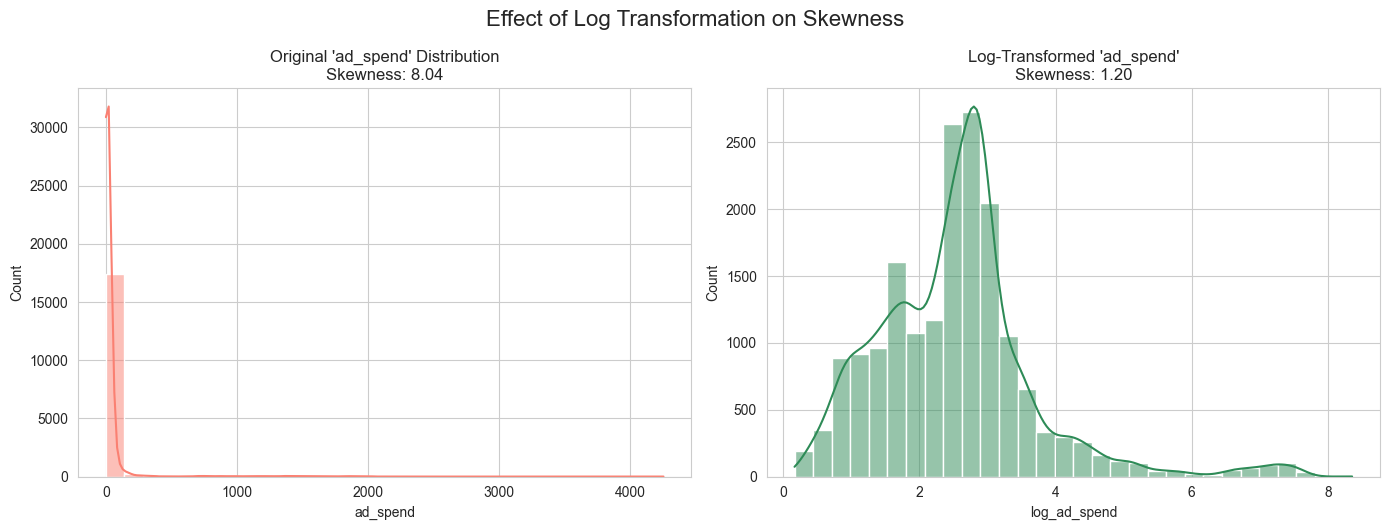

In [20]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['ad_spend'], kde=True, bins=30, color='salmon')
plt.title(f"Original 'ad_spend' Distribution\nSkewness: {original_skew:.2f}")

plt.subplot(1, 2, 2)
sns.histplot(df['log_ad_spend'], kde=True, bins=30, color='seagreen')
plt.title(f"Log-Transformed 'ad_spend'\nSkewness: {log_skew:.2f}")

plt.tight_layout()
plt.suptitle("Effect of Log Transformation on Skewness", fontsize=16, y=1.05)
plt.show()


### 3.3 Feature Engineering
**Why:** Creating features like 'FamilySize' adds predictive value.

In [22]:
# Calculate click_through_rate from missing values (if needed)
# Fill missing click_through_rate with median
df['click_through_rate'] = df['click_through_rate'].fillna(df['click_through_rate'].median())

# Create engagement score
df['engagement_score'] = df['impressions'] * df['click_through_rate']

# Create ROI metric 
df['roi_estimate'] = (df['impressions'] * df['click_through_rate'] * 0.01) / (df['ad_spend'] + 1)

# Create interaction features
df['price_discount_interaction'] = df['price'] * (1 - df['discount_rate'])
df['competition_seasonality'] = df['competition_index'] * df['seasonality_index']

# Campaign efficiency metrics
df['impressions_per_dollar'] = df['impressions'] / (df['ad_spend'] + 1)
df['reach_per_dollar'] = df['market_reach'] / (df['ad_spend'] + 1)

df[['ad_spend', 'impressions', 'engagement_score', 'roi_estimate', 'impressions_per_dollar']].head()

,ad_spend,impressions,engagement_score,roi_estimate,impressions_per_dollar
0,9.00,817,0.8170,0.000817,81.700000
1,3.35,2289,146.4960,0.336772,526.206897
2,2.55,14697,2216.3076,6.243120,4140.000000
3,2.95,17578,3454.0770,8.744499,4450.126582
4,15.00,6280,125.6000,0.078500,392.500000


### 3.4 Clean Categorical Columns
**Why:** 'Title' correlates with age, gender, and social status.

In [23]:
# Clean columns
df['region'] = df['region'].str.strip().str.title()
df['channel'] = df['channel'].str.strip().str.title()
df['channel'] = df['channel'].str.replace('_', ' ').str.replace('Socail', 'Social')
df['channel'] = df['channel'].str.replace('Tv', 'TV')

# Create clean table
print("\n" + "="*90)
print(" CATEGORICAL COLUMNS SUMMARY")
print("="*90)

print(f"{'Column':<20} {'Unique Count':<15} {'Unique Values'}")
print("-"*90)

# Region
regions = ', '.join(sorted(df['region'].unique()))
print(f"{'Region':<20} {df['region'].nunique():<15} {regions}")

# Channel
channels = ', '.join(sorted(df['channel'].unique()))
print(f"{'Channel':<20} {df['channel'].nunique():<15} {channels}")

# Product Category
products = ', '.join(sorted(df['product_category'].unique()))
print(f"{'Product Category':<20} {df['product_category'].nunique():<15} {products}")

# Customer Segment
segments = ', '.join(sorted(df['customer_segment'].unique()))
print(f"{'Customer Segment':<20} {df['customer_segment'].nunique():<15} {segments}")

print("="*90)


 CATEGORICAL COLUMNS SUMMARY
Column               Unique Count    Unique Values
------------------------------------------------------------------------------------------
Region               7               Central, East, Norht, Nort, North, South, West
Channel              7               Affiliate, Email, Influencer, Search, Social Media, Socialmedia, TV
Product Category     6               General, Kitchen, Lighting, Seasonal, Stationery, Storage
Customer Segment     3               Budget, Premium, Standard


## 🧮 4. Data Encoding
Encoding converts categorical variables into numerical formats suitable for ML.

### 4.1 Label Encoding (For Ordinal Features)
**Before:** `Sex` → ['male', 'female']

**After:** `Sex_encoded` → [1, 0]

In [24]:
from sklearn.preprocessing import LabelEncoder
segment_order = {'Budget': 0, 'Standard': 1, 'Premium': 2}
df['customer_segment_encoded'] = df['customer_segment'].map(segment_order)

df[['customer_segment', 'customer_segment_encoded']].head()


,customer_segment,customer_segment_encoded
0,Standard,1
1,Premium,2
2,Budget,0
3,Premium,2
4,Premium,2


### 4.2 One-Hot Encoding (For Nominal Features)
**Before:** `Embarked` → C, Q, S

**After:** `Embarked_Q`, `Embarked_S`

In [25]:
df = pd.get_dummies(df, columns=['channel', 'region', 'product_category'], 
                     prefix=['channel', 'region', 'category'], drop_first=True)

print("Shape after one-hot encoding:", df.shape)

Shape after one-hot encoding: (18000, 48)


In [26]:
df.head(3)

,id,customer_segment,ad_spend,price,discount_rate,market_reach,impressions,click_through_rate,competition_index,seasonality_index,...,region_Norht,region_Nort,region_North,region_South,region_West,category_Kitchen,category_Lighting,category_Seasonal,category_Stationery,category_Storage
0,1,Standard,9.00,0.75,0.2782,32.0,817,0.0010,3.34,1.000000,...,False,True,False,False,False,False,False,False,False,False
1,2,Premium,3.35,3.35,0.0912,61.0,2289,0.0640,4.44,0.366025,...,False,False,True,False,False,False,False,False,False,False
2,3,Budget,2.55,2.55,0.1997,461.0,14697,0.1508,3.31,0.366025,...,False,False,True,False,False,False,False,False,False,False


### 4.3 Ordinal Encoding (For Ordered Categories)
**Before:** AgeGroup → ['Child', 'Teen', 'Adult', 'Senior']

**After:** AgeGroup_Ordinal → [0, 1, 2, 3]

In [27]:
ad_spend_order = {'Low': 0, 'Medium': 1, 'High': 2, 'Very High': 3}
df['ad_spend_category_ordinal'] = df['ad_spend_category'].map(ad_spend_order)

# Create clv_category ordinal
clv_order = {'Low Value': 0, 'Medium Value': 1, 'High Value': 2, 'Premium': 3}
df['clv_category_ordinal'] = df['clv_category'].map(clv_order)

df[['ad_spend_category', 'ad_spend_category_ordinal', 'clv_category', 'clv_category_ordinal']].head()

,ad_spend_category,ad_spend_category_ordinal,clv_category,clv_category_ordinal
0,Low,0,Low Value,0
1,Low,0,Medium Value,1
2,Low,0,Medium Value,1
3,Low,0,Medium Value,1
4,Low,0,Low Value,0


### 4.4 Binary Encoding (For High-Cardinality Columns)
**Why:** Reduces dimensionality vs. one-hot encoding.
> Install `category_encoders` if you'd like to try:
```bash
pip install category-encoders
```

## 📏 5. Data Scaling
Scaling is essential when features differ in range — especially for distance-based models.

### 5.1 Min-Max Scaling
**Range:** [0, 1]

In [28]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df['ad_spend_minmax'] = scaler.fit_transform(df[['ad_spend']])
df[['ad_spend', 'ad_spend_minmax']].head()


,ad_spend,ad_spend_minmax
0,9.00,0.002073
1,3.35,0.000745
2,2.55,0.000557
3,2.95,0.000651
4,15.00,0.003484


### 5.2 Standardization (Z-score)
**Mean = 0, Std = 1**

In [29]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df['ad_spend_std'] = scaler.fit_transform(df[['ad_spend']])
df[['ad_spend', 'ad_spend_std']].head()

,ad_spend,ad_spend_std
0,9.00,-0.181504
1,3.35,-0.211758
2,2.55,-0.216042
3,2.95,-0.213900
4,15.00,-0.149375


### 5.3 Robust Scaling
**Why:** Handles outliers by using median and IQR.

In [30]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
df['ad_spend_robust'] = scaler.fit_transform(df[['ad_spend']])
df[['ad_spend', 'ad_spend_robust']].head()

,ad_spend,ad_spend_robust
0,9.00,-0.199313
1,3.35,-0.587629
2,2.55,-0.642612
3,2.95,-0.615120
4,15.00,0.213058


### 5.4 MaxAbs Scaling
**Preserves sparsity and scale sign.**

In [31]:
from sklearn.preprocessing import MaxAbsScaler
scaler = MaxAbsScaler()
df['ad_spend_maxabs'] = scaler.fit_transform(df[['ad_spend']])
df[['ad_spend', 'ad_spend_maxabs']].head()

,ad_spend,ad_spend_maxabs
0,9.00,0.002115
1,3.35,0.000787
2,2.55,0.000599
3,2.95,0.000693
4,15.00,0.003526


### 🎯 Target Columns to Scale
```python
cols_to_scale = ['age', 'fare']
```

### 🧮 Different Scalers

In [32]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler

# Select columns to scale (numeric columns)
cols_to_scale = ['ad_spend', 'price', 'discount_rate', 'market_reach', 
                 'impressions', 'click_through_rate', 'competition_index', 
                 'seasonality_index', 'campaign_duration_days', 'customer_lifetime_value']

# Ensure columns exist
cols_to_scale = [col for col in cols_to_scale if col in df.columns]

scalers = {
    "MinMax": MinMaxScaler(),
    "Standard": StandardScaler(),
    "Robust": RobustScaler(),
    "MaxAbs": MaxAbsScaler()
}

scaled_data = {}

for name, scaler in scalers.items():
    scaled = scaler.fit_transform(df[cols_to_scale])
    scaled_df = pd.DataFrame(scaled, columns=[f'{col}_{name}' for col in cols_to_scale])
    scaled_data[name] = scaled_df
    df = pd.concat([df, scaled_df], axis=1)

print("Columns after scaling:", df.columns.tolist()[:10], "...")

Columns after scaling: ['id', 'customer_segment', 'ad_spend', 'price', 'discount_rate', 'market_reach', 'impressions', 'click_through_rate', 'competition_index', 'seasonality_index'] ...


### 📊 Visual Comparison of Scaling Methods

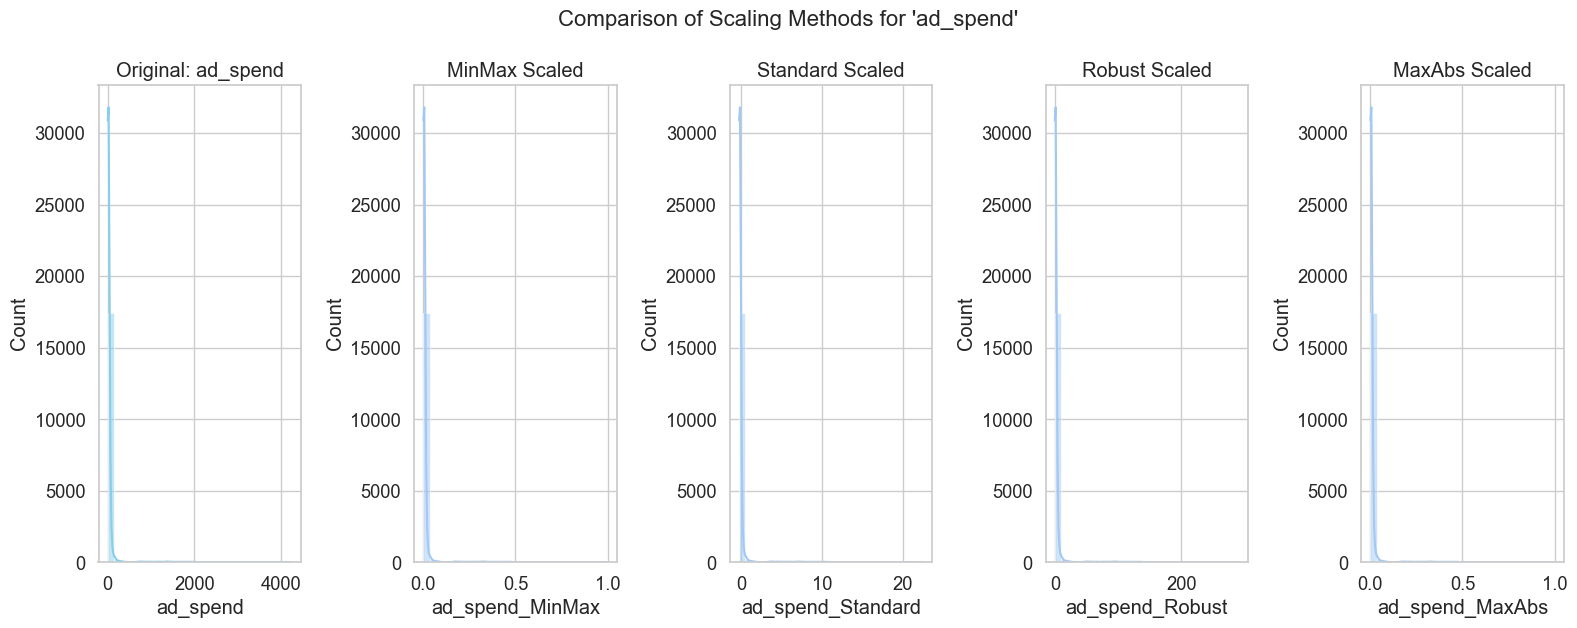

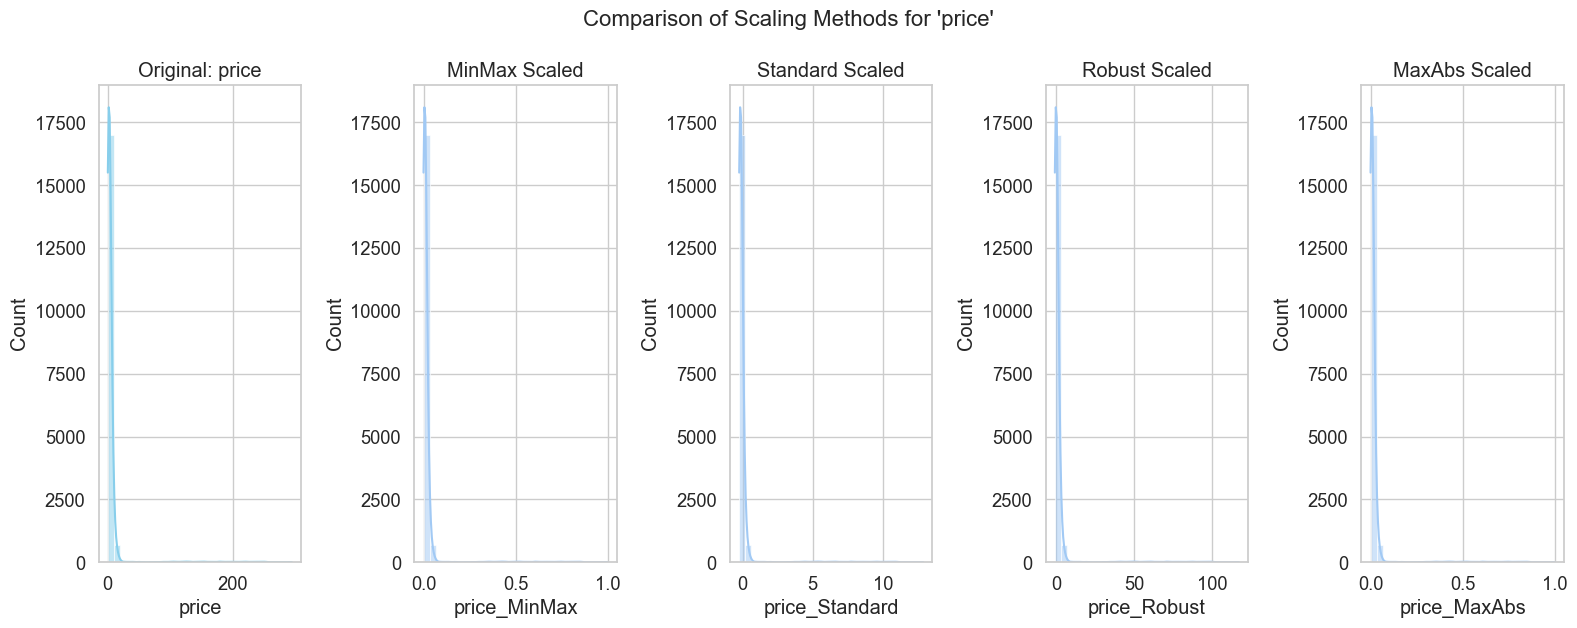

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up Seaborn styling
sns.set(style="whitegrid", palette="pastel", font_scale=1.2)

# Plotting before and after scaling for each scaler
for col in cols_to_scale[:2]:  # Show first 2 features for brevity
    plt.figure(figsize=(16, 6))

    # Original distribution
    plt.subplot(1, len(scalers) + 1, 1)
    sns.histplot(df[col].dropna(), kde=True, bins=30, color='skyblue')
    plt.title(f"Original: {col}")

    # Scaled distributions
    for i, scaler_name in enumerate(scalers.keys(), start=2):
        plt.subplot(1, len(scalers) + 1, i)
        sns.histplot(df[f"{col}_{scaler_name}"], kde=True, bins=30)
        plt.title(f"{scaler_name} Scaled")

    plt.tight_layout()
    plt.suptitle(f"Comparison of Scaling Methods for '{col}'", fontsize=16, y=1.05)
    plt.show()


## ✅ Summary & Best Practices

### 🔹 Why Do This?
- Cleaning removes inconsistencies and gaps.
- Transformation enhances feature relevance.
- Encoding enables ML algorithms to understand categorical values.
- Scaling makes model optimization smoother and more stable.

### 🔹 Recommendations
- Use **StandardScaler** for most models.
- Use **RobustScaler** if outliers dominate.
- Choose **One-Hot** for nominal and **Ordinal** for ordered categorical variables.
- Use **log transformation** for skewed numeric features.

### Final Dataset Overview

In [34]:
print(f"Final dataset shape: {df.shape}")
print(f"Final columns: {df.columns.tolist()}")
print(f"Memory usage: {df.memory_usage().sum() / 1024**2:.2f} MB")

# Save preprocessed data
df.to_csv('marketing_campaign_preprocessed.csv', index=False)
print("Preprocessed data saved to 'marketing_campaign_preprocessed.csv'")

Final dataset shape: (18000, 94)
Final columns: ['id', 'customer_segment', 'ad_spend', 'price', 'discount_rate', 'market_reach', 'impressions', 'click_through_rate', 'competition_index', 'seasonality_index', 'campaign_duration_days', 'customer_lifetime_value', 'sales_revenue', 'year', 'month', 'day', 'dayofweek', 'quarter', 'ad_spend_category', 'clv_category', 'log_ad_spend', 'log_price', 'log_impressions', 'log_market_reach', 'engagement_score', 'roi_estimate', 'price_discount_interaction', 'competition_seasonality', 'impressions_per_dollar', 'reach_per_dollar', 'customer_segment_encoded', 'channel_Email', 'channel_Influencer', 'channel_Search', 'channel_Social Media', 'channel_Socialmedia', 'channel_TV', 'region_East', 'region_Norht', 'region_Nort', 'region_North', 'region_South', 'region_West', 'category_Kitchen', 'category_Lighting', 'category_Seasonal', 'category_Stationery', 'category_Storage', 'ad_spend_category_ordinal', 'clv_category_ordinal', 'ad_spend_minmax', 'ad_spend_std'